In [1]:
#importing all the libraries.  Matpoltlib is good for basic plots.
#Seaborn works best with statistical data & Pandas.
#For more specific details at: https://seaborn.pydata.org/tutorial/introduction.html
        
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#to read sales items dataset - show 5 rows
ad_data= pd.read_csv('digital_marketing_campaign.csv', encoding ="latin1")
ad_data.head(2)

,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1


In [3]:
#to show the columns & variable type
ad_data.dtypes

CustomerID               int64
Age                      int64
Gender                  object
Income                   int64
CampaignChannel         object
CampaignType            object
AdSpend                float64
ClickThroughRate       float64
ConversionRate         float64
WebsiteVisits            int64
PagesPerVisit          float64
TimeOnSite             float64
SocialShares             int64
EmailOpens               int64
EmailClicks              int64
PreviousPurchases        int64
LoyaltyPoints            int64
AdvertisingPlatform     object
AdvertisingTool         object
Conversion               int64
dtype: object

In [4]:
#Use isnull to check for null (missing data in all columns) 
ad_data.isnull().sum()

CustomerID             0
Age                    0
Gender                 0
Income                 0
CampaignChannel        0
CampaignType           0
AdSpend                0
ClickThroughRate       0
ConversionRate         0
WebsiteVisits          0
PagesPerVisit          0
TimeOnSite             0
SocialShares           0
EmailOpens             0
EmailClicks            0
PreviousPurchases      0
LoyaltyPoints          0
AdvertisingPlatform    0
AdvertisingTool        0
Conversion             0
dtype: int64

In [5]:
ad_data.shape

(8000, 20)

In [6]:
ad_data = ad_data.drop(['AdvertisingPlatform','AdvertisingTool'], axis = 1)
ad_data.head(2)

,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,1


In [7]:
#USe descirbe method to look at the statistical basic information.
ad_data.describe()

,CustomerID,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,11999.50000,43.625500,84664.196750,5000.944830,0.154829,0.104389,24.751625,5.549299,7.727718,49.799750,9.476875,4.467375,4.485500,2490.268500,0.876500
std,2309.54541,14.902785,37580.387945,2838.038153,0.084007,0.054878,14.312269,2.607358,4.228218,28.901165,5.711111,2.856564,2.888093,1429.527162,0.329031
min,8000.00000,18.000000,20014.000000,100.054813,0.010005,0.010018,0.000000,1.000428,0.501669,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9999.75000,31.000000,51744.500000,2523.221165,0.082635,0.056410,13.000000,3.302479,4.068340,25.000000,5.000000,2.000000,2.000000,1254.750000,1.000000
50%,11999.50000,43.000000,84926.500000,5013.440044,0.154505,0.104046,25.000000,5.534257,7.682956,50.000000,9.000000,4.000000,4.000000,2497.000000,1.000000
75%,13999.25000,56.000000,116815.750000,7407.989369,0.228207,0.152077,37.000000,7.835756,11.481468,75.000000,14.000000,7.000000,7.000000,3702.250000,1.000000
max,15999.00000,69.000000,149986.000000,9997.914781,0.299968,0.199995,49.000000,9.999055,14.995311,99.000000,19.000000,9.000000,9.000000,4999.000000,1.000000


In [8]:
#1. Look at Success Metrics for each campaigns
#Conversion rate - calculates the percentage of users who conversion (made a purchase) / total number of users
#ad_data.astype({'Conversion':'float64'})
conversion_rate = ad_data['Conversion'].sum() / len(ad_data) *100
print (f'Conversion Rate: {conversion_rate: .2f}%')

Conversion Rate:  87.65%


In [9]:
#1. Cost per acquisition (CPA): Cost of total campaign / # of acquired customers.
total_cost = ad_data['AdSpend'].sum()
total_customers = len(ad_data[ad_data['Conversion'] == 1])
cpa = total_cost / total_customers
print(f'Cost Per Acquistion (CPA): €{cpa: .2f}')

Cost Per Acquistion (CPA): € 5705.58


In [10]:
#3. Return on Investment (ROI): Compare the total revenue generated from conversions/Campaign cost

In [11]:
#Click through Rate (CTR) Percentage of clicks relative to views
ctr = (ad_data['ClickThroughRate'].sum()/len(ad_data)) * 100
print(f'Click Through Rate (CTR): {ctr: .2f}%')

Click Through Rate (CTR):  15.48%


In [12]:
#Bounce Rate: visits that left after single visit
single_page_views = len(ad_data[ad_data['PagesPerVisit'] == 1])
total_visits = len(ad_data)
bounce_rate = (single_page_views / total_visits) * 100
print(f'Bounce Rate: {bounce_rate: .2f}%')


Bounce Rate:  0.00%


In [13]:
#Average Transaction Value: Average purchase amount
avg_transaction = ad_data.groupby('CustomerID')['AdSpend'].sum().mean()
#avg_transaction
print(f'Avg Tranasction Value per customer: €{avg_transaction: .2f}') 


Avg Tranasction Value per customer: € 5000.94


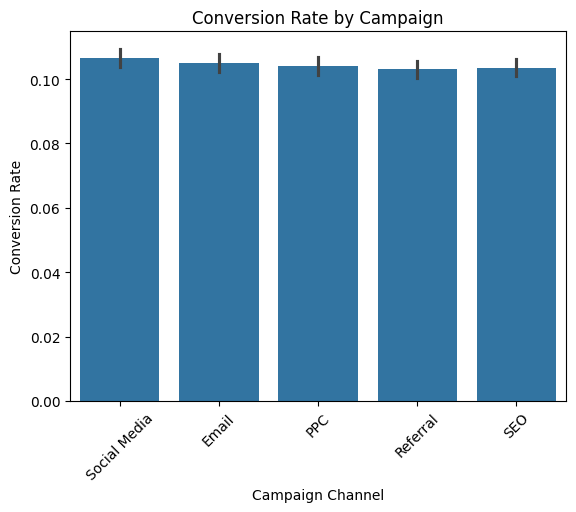

In [14]:
#Conversion rate per channel
sns.barplot(x= 'CampaignChannel', y= 'ConversionRate', data=ad_data)
plt.title('Conversion Rate by Campaign')
plt.xlabel('Campaign Channel')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=45)
plt.show()

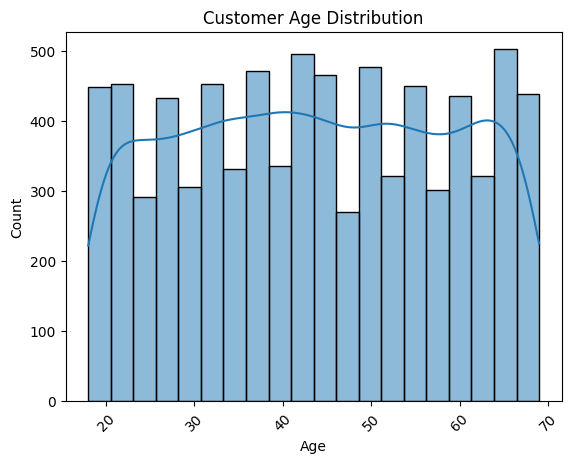

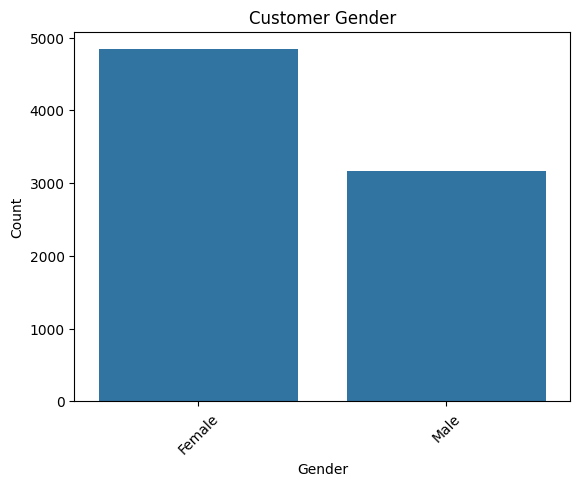

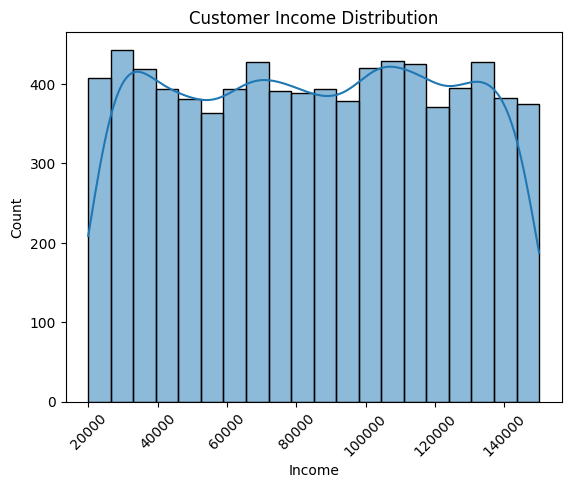

In [15]:
#Demographics of Custers
sns.histplot(ad_data['Age'], bins=20, kde=True)
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

sns.countplot(x ='Gender', data=ad_data)
plt.title('Customer Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

sns.histplot(ad_data['Income'], bins=20, kde=True)
plt.title('Customer Income Distribution')
plt.xlabel('Income')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

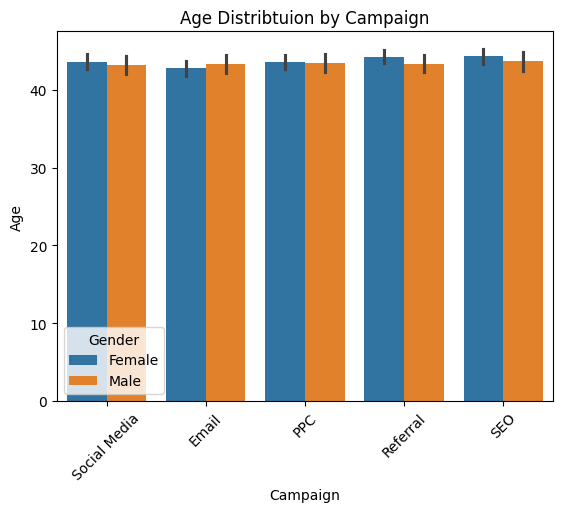

In [16]:
sns.barplot(x ='CampaignChannel', y= 'Age', hue = 'Gender', data=ad_data)
plt.title('Age Distribtuion by Campaign')
plt.xlabel('Campaign')
plt.ylabel('Age')
plt.legend(title='Gender')
plt.xticks(rotation=45)
plt.show()

In [17]:
#Look at correlations to Conversions. First get the predictors columns. Then ad target variable.
marketing = ad_data[['TimeOnSite','EmailClicks','EmailOpens','AdSpend','PreviousPurchases','Conversion']]
corr = marketing.corr()['Conversion']
corr.nlargest(6).round(2)

Conversion           1.00
TimeOnSite           0.13
EmailClicks          0.13
EmailOpens           0.12
AdSpend              0.12
PreviousPurchases    0.11
Name: Conversion, dtype: float64

In [18]:
#Looking at the correlations - pick out what has medium corelation to BUY.
#import sklearn libraries to create our model.
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score,classification_report, ConfusionMatrixDisplay

#Key variables to try to predict clickd on ad.
predictors = marketing[['TimeOnSite','EmailClicks','EmailOpens','AdSpend','PreviousPurchases']]
targets = marketing['Conversion']
predictors.head(3)

,TimeOnSite,EmailClicks,EmailOpens,AdSpend,PreviousPurchases
0,7.396803,9,6,6497.870068,4
1,5.352549,7,2,3898.668606,2
2,13.794901,2,11,1546.429596,8


In [19]:
#Construct an algorithm that can learn & make predictions for buying.
#To train and test the data - use ratio of 80:20 (80% of the data to train model, 20% to test model).
pred_train,pred_test,tar_train,tar_test = train_test_split(predictors,targets,test_size=.2, random_state = 42)
print('Predictor data for Training: ',pred_train.shape, 'Predictor data for Testing: ',pred_test.shape)

Predictor data for Training:  (6400, 5) Predictor data for Testing:  (1600, 5)


In [20]:
#Scale the features
scaler = StandardScaler()
pred_train_scaled = scaler.fit_transform(pred_train)
pred_test_scaled = scaler.transform(pred_test)

#1. Initialise the Random Forest Classifier model.

model = RandomForestClassifier(n_estimators=100,random_state = 42,class_weight='balanced')
model.fit(pred_train_scaled, pred_test)

#Generate predictions
pred = model.predict(pred_test_scaled)

#4. Evaluate  the accuracy of the model & performance
acc = accuracy_score(pred_test, pred) * 100
print (f'True Classification Accuracy: {acc:.4f} ({acc*100:.1f}%)')
print ('Confusion Matrix:\n', confusion_matrix(tar_test,predictions))

ValueError: Found input variables with inconsistent numbers of samples: [6400, 1600]

In [ ]:
#Extract the True Probabilities for New Customers
combined_data = np.array([
    [30, 100,100],   # Customer 1: age 30, 100 mins of Internet daily usage, time spent
    [50,240,20]     # Customer 2: age 50, 240 mins of Internet daily usage, time spent 
])
#Use predict_proba to get probabilities for each scenario (customer profile)
probabilities = classifier.predict_proba(combined_data)[:,1]

print('\n---Predicted Ad Clicks Likelihood --- ')
print(f'Customer 1 Probability: {probabilities[0]*100:.2f}% chance to click')
print(f'Customer 2 Probability: {probabilities[1]*100:.2f}% chance to click')

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
#Define the variables of the customers
ages = np.array([30,50,80])
internet_hours = np.array([100,50,20])
time_spent =np.array([80,20,20]) 
#combine into a single array
combined_data = np.column_stack((ages,internet_hours,time_spent))
predictions = classifier.predict (combined_data)

fig = plt.figure(figsize= (8,6))
ax = fig.add_subplot(111, projection = '3d')
scatter = ax.scatter(ages, internet_hours, predictions, c=predictions,cmap = 'coolwarm', 
        s=100, edgecolors= 'black')
ax.set_xlabel('Age')
ax.set_ylabel('Internet Hours')
ax.set_zlabel('Predicted Ad Clicks')
ax.set_title('3D View of Cusomter Ad Click Predictions')
fig.colorbar(scatter, ax=ax,label= 'Prediction Value', pad = 0.1)
plt.show()

In [ ]:
#from sklearn.metrics import confusion_matrix
cm = confusion_matrix(tar_test, predictions)

plt.figure(figsize=(6,5))
#creat a heatmap that formats the numbers as integers with labels 
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',cbar= False, 
    xticklabels=['Predicted: No','Predicted: Yes'],
    yticklabels=['Actual: No','Actual: Yes'])
plt.title('Model Evaluation: Confusion Matrix',fontsize=14,pad=15)
plt.xlabel('Model Prediction', fontsize=12)
plt.ylabel('True Category',fontsize=12)
plt.show()

In [ ]:
#the probability that a prospective buyer will 'BUY' the product. 
pred_prob = classifier.predict_proba(pred_test.values)
pred_prob[0,1].round(2)

In [ ]:
#Real time prediction of a user who clicks on the site will 'BUY'
#Define the test scenarios - using 4 predictor 'columns'
scenarios = {
    '60 year old & limited internet: [[60,80]],
    'Only Reviews clicked': [[1,0]],
    'Reviews & Compare Similar': [[1,1,0,0]],
    'All Predctor Pages Clicked': [[1,1,1,1]]
}
#Create an empty list ot gather rows
results_data = []

for description, features in scenarios.items():
    proba_val = classifier.predict_proba(features)[0,1]
    percentage = round(proba_val * 100)

#store scenario and results as a dictionary row.
    results_data.append({
        "Customer Scenario": description,
        "Propensity to Buy": f"{percentage}%"
   })
#To crete a dataframe to display 
df = pd.DataFrame(results_data)
df

In [ ]:
#Export the dataframe to a csv file.
df.to_csv ('customer_propensity_to_buy_report.csv',index=False)